# Backtest 005 — HMM Regime Gate (Best Params + Full HMM Combo)

Combines:
- **Strategy**: TTM Breakout v1/v2/v3 with best params from `ttm_best_params_005.json`
- **Regime**: 2-state walk-forward HMM on VNINDEX (Risk-On / Risk-Off)
- **HMM Combo**: 25% size during Risk-Off

**Analysis**
1. Regime predictive power — forward VNINDEX returns
2. Per-version: Baseline vs HMM combo (full sample)
3. OOS slice — last 40%
4. Trade-level stats by regime at entry


## 1. Imports

In [41]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

import numba as nb
import vectorbt as vbt
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from IPython.display import display

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl     import atr_trailing_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator
from backend.app.services.indicators.common          import shift_2d, count_consecutive_neg_2d, autocorr_2d
from backend.app.services.indicators.kama            import kama_2d, slope_flat_2d
from backend.app.services.indicators.chandelier_exit import _chandelier_nb

plt.style.use('dark_background')
sns.set_palette('husl')
print('imports ok')


imports ok


## 2. Load Data

In [42]:
from backend.app.services.data_loader import load_stocks

BENCHMARK = 'VNINDEX'

df_raw = load_stocks()

open_  = df_raw['open']
high   = df_raw['high']
low    = df_raw['low']
close  = df_raw['close']
volume = df_raw['volume']

valid_syms = close.columns[close.isna().mean() < 0.2]
close  = close[valid_syms].ffill()
high   = high[valid_syms].ffill()
low    = low[valid_syms].ffill()
open_  = open_[valid_syms].ffill()
volume = volume[valid_syms].ffill().fillna(0)

if BENCHMARK in close.columns:
    bm_close  = close[BENCHMARK]
    bm_volume = volume[BENCHMARK]
else:
    bm_close  = close.mean(axis=1)
    bm_volume = volume.mean(axis=1)

print(f'Symbols: {len(valid_syms)}  |  {close.index[0].date()} → {close.index[-1].date()}')


Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2501, 990)  |  2016-06-20 → 2026-06-19
Symbols: 198  |  2016-06-20 → 2026-06-19


## 3. 2-State Walk-Forward HMM Regime

In [43]:
# ── feature engineering on benchmark ─────────────────────────────────────────
W = 20

feat_bm = pd.DataFrame(index=bm_close.index)
feat_bm['log_ret']    = np.log(bm_close / bm_close.shift(1))
feat_bm['volatility'] = feat_bm['log_ret'].rolling(W).std()
feat_bm['momentum']   = np.log(bm_close / bm_close.shift(W))
feat_bm['vol_ratio']  = bm_volume / bm_volume.rolling(W).mean()
feat_bm = feat_bm.dropna()

FEATURE_COLS = ['log_ret', 'volatility', 'momentum', 'vol_ratio']
print(f'Feature matrix: {feat_bm.shape}')

Feature matrix: (2481, 4)


In [44]:
BURN_IN_DAYS  = 252
RANDOM_SEED   = 42
RETRAIN_EVERY = 5   # weekly retraining


In [45]:
def build_wf_regime(
    feat_df,
    feature_cols,
    n_components=2,
    burn_in=252,
    retrain_every=21,
    random_seed=42,
):
    """
    Walk-forward HMM regime labelling (zero lookahead).

    Returns a pd.Series of 'Bull' / 'Neutral' / 'Bear' (or 'Risk-On' / 'Risk-Off'
    for 2-state) indexed to feat_df, with NaN before the first prediction.
    """
    from hmmlearn.hmm import GaussianHMM
    from sklearn.preprocessing import StandardScaler

    feat_arr  = feat_df[feature_cols].values
    dates     = feat_df.index.tolist()
    n_total   = len(dates)
    wf_label  = pd.Series('Unknown', index=feat_df.index, name='regime')

    retrain_indices = list(range(burn_in - 1, n_total - 1, retrain_every))

    for ri, train_end_idx in enumerate(retrain_indices):
        X_train  = feat_arr[:train_end_idx + 1]
        scaler   = StandardScaler()
        X_scaled = scaler.fit_transform(X_train)

        model = GaussianHMM(
            n_components=n_components,
            covariance_type='full',
            n_iter=500,
            random_state=random_seed,
            tol=1e-4,
            verbose=False,
        )
        model.fit(X_scaled)
        states_train = model.predict(X_scaled)

        mean_rets = {
            s: feat_arr[:train_end_idx + 1, 0][states_train == s].mean()
            for s in range(n_components)
        }
        ranked    = sorted(mean_rets, key=mean_rets.get)
        if n_components == 2:
            label_map = {ranked[0]: 'Bear', ranked[1]: 'Bull'}
        else:
            label_map = {ranked[0]: 'Bear', ranked[1]: 'Neutral', ranked[2]: 'Bull'}

        current_label = label_map[states_train[-1]]
        next_idx      = retrain_indices[ri + 1] if ri + 1 < len(retrain_indices) else n_total
        wf_label.iloc[train_end_idx + 1:next_idx] = current_label

    return wf_label

print('build_wf_regime defined')


build_wf_regime defined


In [46]:
print('Running 2-state walk-forward HMM …')
regime_wf = build_wf_regime(
    feat_bm, FEATURE_COLS,
    n_components  = 2,
    burn_in       = BURN_IN_DAYS,
    retrain_every = RETRAIN_EVERY,
    random_seed   = RANDOM_SEED,
)
# 2-state: Bear → Risk-Off  Bull → Risk-On
regime_wf = regime_wf.replace({'Bear': 'Risk-Off', 'Bull': 'Risk-On'})
regime_on_close = regime_wf.reindex(close.index)
print(regime_wf.value_counts().to_string())

regime_aligned = regime_on_close  # alias used by run_all / oos


Running 2-state walk-forward HMM …


Model is not converging.  Current: -3202.0188847110157 is not greater than -3202.018883822728. Delta is -8.88287559064338e-07
Model is not converging.  Current: -3248.6674028620932 is not greater than -3248.6674015959534. Delta is -1.2661398614000063e-06


regime
Risk-On     940
Risk-Off    844
Unknown     697


## 4. Predictive Power — Forward VNINDEX Returns

In [47]:
# Regime at close t → forward return from t+1 (no lookahead)
eval_bm = feat_bm.copy()
eval_bm['regime_wf'] = regime_wf.reindex(eval_bm.index)
eval_bm = eval_bm[eval_bm['regime_wf'] != 'Unknown'].copy()

bm_px = bm_close.reindex(eval_bm.index)
for h in [1, 5, 21, 63]:
    eval_bm[f'fwd_{h}d'] = np.log(bm_px.shift(-h) / bm_px)

HORIZONS = [1, 5, 21, 63]
rows = []
for h in HORIZONS:
    col = f'fwd_{h}d'
    g = eval_bm.groupby('regime_wf')[col].agg(['mean', 'std', 'count'])
    g['ann_mean_%'] = g['mean'] * (252 / h) * 100
    g['horizon'] = h
    rows.append(g.reset_index())
fwd_table = pd.concat(rows, ignore_index=True)
display(fwd_table.pivot(index='regime_wf', columns='horizon', values='ann_mean_%').round(2))

# Risk-On − Risk-Off spread at 21d
g21 = eval_bm.groupby('regime_wf')['fwd_21d'].mean()
if {'Risk-On', 'Risk-Off'}.issubset(g21.index):
    spread = (g21['Risk-On'] - g21['Risk-Off']) * (252 / 21) * 100
    print(f'Risk-On − Risk-Off forward-21d spread (ann. %): {spread:.2f}')


horizon,1,5,21,63
regime_wf,,,,
Risk-Off,13.74,11.59,11.67,18.79
Risk-On,10.76,12.71,13.10,5.82


Risk-On − Risk-Off forward-21d spread (ann. %): 1.44


## 5. TTM Strategy Helpers

In [48]:
def compute_signals(
    close, high, low,
    # BB params
    bb_window:                int   = 16,
    bb_multiplier:            float = 1.0,
    bb_matype:                int   = 0,
    # Keltner params
    kc_window:                int   = 40,
    kc_multiplier:            float = 1.2,
    kc_atr_period:            int   = 10,
    # TTM oscillator params
    donichan_window:          int   = 12,
    osc_smoothing_period:     int   = 10,
    # Entry version
    entry_version:            str   = 'v3',
    consecutive_neg_threshold:int   = 7,
    # Williams VIX Fix (v3 only)
    william_vix_period:       int   = 20,
    # KAMA slope filter (v1, v2 only)
    use_kama_slope:           bool  = True,
    kama_period:              int   = 10,
    kama_fast:                int   = 2,
    kama_slow:                int   = 30,
    kama_slope_win:           int   = 5,
    flat_threshold_pct:       float = 1.0,
    # 5-day return autocorrelation filter
    use_autocorr:             bool  = False,
    autocorr_ret_period:      int   = 5,
    autocorr_window:          int   = 60,
    autocorr_threshold:       float = 0.0,
):
    """
    Compute TTM Breakout entry signals.

    Indicators are computed lazily — only what the requested version needs:
      v1, v2 : BB + Keltner (both bands) + TTM histogram + KAMA slope
      v3     : BB + Keltner (upper only) + TTM histogram + WVF
      all    : autocorr filter when use_autocorr=True
    """
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    close_np    = close.to_numpy()
    bb_upper_np = bb.upperband.to_numpy()
    bb_lower_np = bb.lowerband.to_numpy()
    ema_np      = ema.real.to_numpy()
    atr_np      = atr.real.to_numpy()
    kc_upper_np = ema_np + kc_multiplier * atr_np

    hh  = MAX.run(high,  timeperiod=donichan_window).real.to_numpy()
    ll  = MAX.run(low,   timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    if entry_version in ('v1', 'v2'):
        kc_lower_np = ema_np - kc_multiplier * atr_np
        if use_kama_slope:
            kama_np = kama_2d(close_np.astype(np.float64), kama_period, kama_fast, kama_slow)
            flat_np = slope_flat_2d(kama_np, kama_slope_win, flat_threshold_pct)
        else:
            flat_np = np.ones_like(close_np, dtype=np.bool_)
    elif entry_version == 'v3':
        _, _, _, wvf_signal = williams_vix_fix_indicator(
            close, high, low,
            period=william_vix_period, mult=bb_multiplier, bbl=bb_window,
            lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
        )
        wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()

    if use_autocorr:
        acf_np     = autocorr_2d(close_np.astype(np.float64),
                                 ret_period=autocorr_ret_period, window=autocorr_window)
        acf_filter = acf_np > autocorr_threshold
    else:
        acf_filter = np.ones_like(close_np, dtype=np.bool_)

    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        entries_np = no_sqz_np & (ttms_np > 0) & flat_np & acf_filter
    elif entry_version == 'v2':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        ttms_1 = shift_2d(ttms_np, 1); ttms_2 = shift_2d(ttms_np, 2); ttms_3 = shift_2d(ttms_np, 3)
        crossed_now  = (ttms_1 < 0) & (ttms_np > 0)
        crossed_1ago = (ttms_2 < 0) & (ttms_1  > 0)
        crossed_2ago = (ttms_3 < 0) & (ttms_2  > 0)
        entries_np = no_sqz_np & (
            crossed_now | ((ttms_np > ttms_1) & crossed_1ago) | ((ttms_np > ttms_2) & crossed_2ago)
        ) & flat_np & acf_filter
    else:
        squeeze_diff_np = bb_upper_np - kc_upper_np
        consec_neg      = count_consecutive_neg_2d(ttms_np)
        entry_2 = (
            (shift_2d(squeeze_diff_np, 1) < 0) & (squeeze_diff_np > 0)
            & (consec_neg > consecutive_neg_threshold)
        )
        entries_np = entry_2 | wvf_np

    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(
    close, high, low,
    # ATR trailing stop (default, used when chand_length is None)
    atr_multiplier:   float = 1.9,
    atr_period:       int   = 10,
    # Chandelier Exit (used when chand_length is provided)
    chand_length:     int   = None,
    chand_mult:       float = None,
    entries                 = None,
    max_hold_days:    int   = 30,
    # shared
    low_stop_lookback: int  = 5,
    return_line:      bool  = False,
):
    """
    Returns (exits_df, sl_stop_df).

    Uses Chandelier Exit when chand_length/chand_mult are provided,
    ATR trailing stop otherwise.
    With return_line=True (chandelier only) also returns (line_df, dir_df).
    """
    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    if chand_length is not None and chand_mult is not None:
        atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
            high, low, close, timeperiod=chand_length
        ).real
        chand, direction = _chandelier_nb(
            close.to_numpy().astype(np.float64),
            high.to_numpy().astype(np.float64),
            low.to_numpy().astype(np.float64),
            atr_raw.to_numpy().astype(np.float64),
            float(chand_mult), int(chand_length),
        )
        dir_df   = pd.DataFrame(direction, index=close.index, columns=close.columns)
        line_df  = pd.DataFrame(chand,     index=close.index, columns=close.columns)
        exits_df = (dir_df == -1) & (dir_df.shift(1) == 1)
        if return_line:
            return exits_df, sl_stop_df, line_df, dir_df
    else:
        atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
            high, low, close, timeperiod=atr_period
        )
        ATRTrailing = vbt.IndicatorFactory(
            input_names=['close', 'atr'],
            param_names=['atr_multiplier'],
            output_names=['atr_trailing'],
        ).from_apply_func(atr_trailing_nb)
        atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
        exits_df = close.vbt.crossed_below(atr_sl.atr_trailing)

    return exits_df, sl_stop_df


print('Signal functions defined')


Signal functions defined


In [49]:
@nb.njit
def _early_exit_nb(close_2d, low_2d, entries_2d, window, pct):
    """
    For each symbol: after an entry, if the bar LOW drops > pct from entry close
    within the first  bars, emit an exit signal.
    Uses low (not close) so intraday wicks are captured as true MAE.
    """
    n_rows, n_cols = close_2d.shape
    out = np.zeros((n_rows, n_cols), dtype=np.bool_)
    for col in range(n_cols):
        entry_bar   = -1
        entry_close = np.nan
        for row in range(n_rows):
            if entries_2d[row, col]:
                entry_bar   = row
                entry_close = close_2d[row, col]
            if entry_bar >= 0:
                bars_since = row - entry_bar
                if 1 <= bars_since <= window:
                    mae = (entry_close - low_2d[row, col]) / entry_close
                    if mae > pct:
                        out[row, col] = True
                        entry_bar = -1   # stop watching after firing
    return out


def early_exit_signal(close, low, entries, window=5, pct=0.05):
    """Returns a boolean exit DataFrame: fires when MAE (low-based) > pct within  bars of entry."""
    result = _early_exit_nb(
        close.to_numpy().astype(np.float64),
        low.to_numpy().astype(np.float64),
        entries.to_numpy().astype(np.bool_),
        window, pct,
    )
    return pd.DataFrame(result, index=close.index, columns=close.columns)


@nb.njit
def _max_hold_exit_nb(entries_2d, max_hold_days):
    """Exit when bars held since last entry exceed max_hold_days."""
    n_rows, n_cols = entries_2d.shape
    out = np.zeros((n_rows, n_cols), dtype=np.bool_)
    for col in range(n_cols):
        entry_bar = -1
        for row in range(n_rows):
            if entries_2d[row, col]:
                entry_bar = row
            if entry_bar >= 0:
                if row - entry_bar > max_hold_days:
                    out[row, col] = True
                    entry_bar = -1
    return out


def max_hold_exit_signal(entries, max_hold_days=160):
    """Exit when position held longer than max_hold_days (daily bars)."""
    result = _max_hold_exit_nb(entries.to_numpy().astype(np.bool_), max_hold_days)
    return pd.DataFrame(result, index=entries.index, columns=entries.columns)


print('early_exit_signal defined (MAE = low-based)')
print('max_hold_exit_signal defined (>30d default)')

print('Numba helpers compiled')


early_exit_signal defined (MAE = low-based)
max_hold_exit_signal defined (>30d default)
Numba helpers compiled


## 6. Load Best Params

In [50]:
import json as _json
with open('../backend/assets/ttm_best_params_005.json') as _f:
    ALL_BEST = _json.load(_f)

for ver, p in ALL_BEST.items():
    print(f"{ver}: bb={p['bb_window']}x{p['bb_multiplier']}x{p['bb_matype']} kc={p['kc_window']}"
          f"  chand={p.get('chand_length','N/A')}x{p.get('chand_mult','N/A')}")


v1: bb=14x1.2000000000000002x3 kc=40  chand=N/AxN/A
v2: bb=14x0.8x3 kc=46  chand=N/AxN/A
v3: bb=13x1.6x3 kc=54  chand=N/AxN/A


## 7. Regime-Aware Indicators (ATR Cap + RS Filter)

In [51]:
def broadcast_mask(series_mask, columns):
    """Broadcast a boolean Series (dates,) to a DataFrame (dates × symbols)."""
    return pd.DataFrame(
        np.tile(series_mask.values.reshape(-1, 1), (1, len(columns))),
        index=series_mask.index, columns=columns,
    ).astype(bool)


In [52]:
# ── ATR-based volatility stop cap (for Risk-Off tightening) ───────────────────
ATR_PERIOD = 14
ATR_MULT   = 1.5   # Risk-Off stop = min(chandelier_sl, ATR_MULT * ATR / close)

_ATR = vbt.IndicatorFactory.from_talib('ATR')
atr_df       = _ATR.run(high, low, close, timeperiod=ATR_PERIOD).real
atr_stop_cap = (ATR_MULT * atr_df / close).clip(lower=0.01)
atr_stop_cap = atr_stop_cap.reindex(columns=valid_syms).ffill().bfill()

print(f'ATR stop cap  mean={atr_stop_cap.mean().mean():.4f}  '
      f'median={atr_stop_cap.median().median():.4f}')



ATR stop cap  mean=nan  median=nan


## 8. Run v1 / v2 / v3 — Baseline vs HMM Combo (Full Sample)

In [53]:
INIT_CASH = 100
SIZING    = {'Risk-On': 1, 'Risk-Off': 0.5, 'Unknown': 1.0}

portfolios = {}   # (ver, "base"|"hmm") → vbt.Portfolio

for ver in ['v1', 'v2', 'v3']:
    p = ALL_BEST[ver]
    print(f'\n── {ver} ──────────────────────────────────')

    entries_raw = compute_signals(
        close, high, low,
        bb_window                 = p['bb_window'],
        bb_multiplier             = p['bb_multiplier'],
        bb_matype                 = p['bb_matype'],
        kc_window                 = p['kc_window'],
        kc_multiplier             = p['kc_multiplier'],
        kc_atr_period             = p['kc_atr_period'],
        entry_version             = ver,
        consecutive_neg_threshold = p.get('consecutive_neg_threshold', 7),
        william_vix_period        = p.get('william_vix_period', 20),
        use_kama_slope            = ('kama_period' in p),
        kama_period               = p.get('kama_period', 10),
        kama_fast                 = p.get('kama_fast', 2),
        kama_slow                 = p.get('kama_slow', 30),
        kama_slope_win            = p.get('kama_slope_win', 5),
        flat_threshold_pct        = p.get('flat_threshold_pct', 1.0),
    )

    exits, sl_stop = compute_exits(
        close, high, low,
        atr_multiplier    = p.get('atr_multiplier', 1.9),
        atr_period        = p.get('atr_period', 10),
        chand_length      = p.get('chand_length'),
        chand_mult        = p.get('chand_mult'),
        entries           = entries_raw,
        max_hold_days     = 30,
        low_stop_lookback = p['low_stop_lookback'],
    )

    # ── baseline ──────────────────────────────────────────────────────────────
    pf_b = vbt.Portfolio.from_signals(
        close=close, entries=entries_raw, exits=exits, sl_stop=sl_stop,
        freq='1d', group_by=False, cash_sharing=False, init_cash=INIT_CASH,
    )
    portfolios[(ver, 'base')] = pf_b

    # ── HMM combo: tighter stop during Risk-Off + position sizing ─────────────
    risk_off_df = broadcast_mask(regime_aligned == 'Risk-Off', valid_syms)
    sl_stop_hmm = sl_stop.where(
        ~risk_off_df,
        np.minimum(sl_stop.values, atr_stop_cap.values),
    ).fillna(sl_stop)

    size_frac    = regime_aligned.map(SIZING).fillna(1.0)
    size_frac_df = pd.DataFrame(
        np.tile(size_frac.values.reshape(-1, 1), (1, len(valid_syms))),
        index=size_frac.index, columns=valid_syms,
    )
    share_size_df = (size_frac_df * INIT_CASH / close).fillna(0).replace([np.inf, -np.inf], 0)

    pf_h = vbt.Portfolio.from_signals(
        close=close, entries=entries_raw, exits=exits,
        sl_stop=sl_stop_hmm, size=share_size_df,
        freq='1d', group_by=False, cash_sharing=False, init_cash=INIT_CASH,
    )
    portfolios[(ver, 'hmm')] = pf_h

    s_b = pf_b.sharpe_ratio().mean(); s_h = pf_h.sharpe_ratio().mean()
    dd_b = pf_b.max_drawdown().mean(); dd_h = pf_h.max_drawdown().mean()
    print(f'  Baseline : Sharpe={s_b:.3f}  MaxDD={dd_b:.1%}')
    print(f'  HMM combo: Sharpe={s_h:.3f}  MaxDD={dd_h:.1%}  '
          f'(Sharpe {s_h-s_b:+.3f}  MaxDD {dd_h-dd_b:+.1%})')

print('\nAll done.')



── v1 ──────────────────────────────────
  Baseline : Sharpe=0.631  MaxDD=-46.9%
  HMM combo: Sharpe=0.651  MaxDD=-34.2%  (Sharpe +0.020  MaxDD +12.8%)

── v2 ──────────────────────────────────
  Baseline : Sharpe=0.605  MaxDD=-46.8%
  HMM combo: Sharpe=0.605  MaxDD=-35.1%  (Sharpe +0.000  MaxDD +11.7%)

── v3 ──────────────────────────────────
  Baseline : Sharpe=0.604  MaxDD=-48.8%
  HMM combo: Sharpe=0.605  MaxDD=-35.3%  (Sharpe +0.001  MaxDD +13.5%)

All done.


## 9. Stats Table

In [54]:
def full_stats(pf, name):
    s = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    return pd.Series({
        'Name':             name,
        'Sharpe mean':      round(s.mean(), 3),
        'Sharpe median':    round(s.median(), 3),
        'Sharpe > 0':       f"{(s > 0).sum()}/{len(s)}",
        'Sharpe > 1':       f"{(s > 1).sum()}/{len(s)}",
        'Sortino mean':     round(pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).mean(), 3),
        'Calmar mean':      round(pf.calmar_ratio().replace([np.inf,-np.inf],np.nan).mean(), 3),
        'Total Ret mean':   f"{pf.total_return().replace([np.inf,-np.inf],np.nan).mean():.1%}",
        'Total Ret median': f"{pf.total_return().replace([np.inf,-np.inf],np.nan).median():.1%}",
        'Max DD mean':      f"{pf.max_drawdown().replace([np.inf,-np.inf],np.nan).mean():.1%}",
        'Max DD worst':     f"{pf.max_drawdown().replace([np.inf,-np.inf],np.nan).min():.1%}",
        'N Trades':         int(pf.trades.count().sum()),
        'Win Rate':         f"{pf.trades.win_rate().mean():.1%}",
        'Profit Factor':    round(pf.trades.profit_factor().replace([np.inf,-np.inf],np.nan).mean(), 3),
    })

rows = []
for ver in ['v1', 'v2', 'v3']:
    rows.append(full_stats(portfolios[(ver, 'base')], f'{ver} Baseline'))
    rows.append(full_stats(portfolios[(ver, 'hmm')],  f'{ver} HMM combo'))

display(pd.DataFrame(rows).set_index('Name').T)


Name,v1 Baseline,v1 HMM combo,v2 Baseline,v2 HMM combo,v3 Baseline,v3 HMM combo
Sharpe mean,0.631,0.651,0.605,0.605,0.604,0.605
Sharpe median,0.644,0.668,0.635,0.635,0.596,0.576
Sharpe > 0,188/198,189/198,186/198,188/198,186/198,189/198
Sharpe > 1,29/198,39/198,28/198,32/198,26/198,25/198
Sortino mean,0.99,1.06,0.944,0.975,0.934,0.966
Calmar mean,0.427,0.429,0.41,0.389,0.402,0.379
Total Ret mean,332.4%,122.3%,311.0%,113.4%,405.0%,110.2%
Total Ret median,187.9%,113.7%,159.1%,104.0%,173.3%,94.9%
Max DD mean,-46.9%,-34.2%,-46.8%,-35.1%,-48.8%,-35.3%
Max DD worst,-89.4%,-87.6%,-96.0%,-95.9%,-91.2%,-90.6%


## 10. OOS Slice — Last 40%

In [55]:
split_idx = int(len(close) * 0.6)
oos_start = close.index[split_idx]
print(f'OOS from {oos_start.date()}  ({len(close)-split_idx} bars)')

SIZING    = {'Risk-On': 1, 'Risk-Off': 0.5, 'Unknown': 1.0}
INIT_CASH = 100

oos_rows = []
for ver in ['v1', 'v2', 'v3']:
    p = ALL_BEST[ver]
    entries_raw = compute_signals(
        close, high, low,
        bb_window                 = p['bb_window'],
        bb_multiplier             = p['bb_multiplier'],
        bb_matype                 = p['bb_matype'],
        kc_window                 = p['kc_window'],
        kc_multiplier             = p['kc_multiplier'],
        kc_atr_period             = p['kc_atr_period'],
        entry_version             = ver,
        consecutive_neg_threshold = p.get('consecutive_neg_threshold', 7),
        william_vix_period        = p.get('william_vix_period', 20),
        use_kama_slope            = ('kama_period' in p),
        kama_period               = p.get('kama_period', 10),
        kama_fast                 = p.get('kama_fast', 2),
        kama_slow                 = p.get('kama_slow', 30),
        kama_slope_win            = p.get('kama_slope_win', 5),
        flat_threshold_pct        = p.get('flat_threshold_pct', 1.0),
    )

    exits, sl_stop = compute_exits(
        close, high, low,
        atr_multiplier    = p.get('atr_multiplier', 1.9),
        atr_period        = p.get('atr_period', 10),
        chand_length      = p.get('chand_length'),
        chand_mult        = p.get('chand_mult'),
        entries           = entries_raw,
        max_hold_days     = 30,
        low_stop_lookback = p['low_stop_lookback'],
    )

    risk_off_df = broadcast_mask(regime_aligned == 'Risk-Off', valid_syms)
    sl_stop_hmm = sl_stop.where(
        ~risk_off_df,
        np.minimum(sl_stop.values, atr_stop_cap.values),
    ).fillna(sl_stop)

    for kind, ent, sl in [
        ('base', entries_raw, sl_stop),
        ('hmm',  entries_raw, sl_stop_hmm),
    ]:
        cl  = close.loc[oos_start:]
        e   = ent.loc[oos_start:]
        ex  = exits.loc[oos_start:]
        sl_ = sl.loc[oos_start:]

        if kind == 'hmm':
            size_frac    = regime_aligned.map(SIZING).fillna(1.0)
            size_frac_df = pd.DataFrame(
                np.tile(size_frac.values.reshape(-1, 1), (1, len(valid_syms))),
                index=size_frac.index, columns=valid_syms,
            )
            share_size_df = (size_frac_df * INIT_CASH / close).fillna(0).replace([np.inf, -np.inf], 0)
            pf = vbt.Portfolio.from_signals(
                close=cl, entries=e, exits=ex, sl_stop=sl_,
                size=share_size_df.loc[oos_start:],
                freq='1d', group_by=False, cash_sharing=False, init_cash=INIT_CASH,
            )
        else:
            pf = vbt.Portfolio.from_signals(
                close=cl, entries=e, exits=ex, sl_stop=sl_,
                freq='1d', group_by=False, cash_sharing=False, init_cash=INIT_CASH,
            )
        lbl = f'{ver} {"Baseline" if kind=="base" else "HMM combo"}'
        oos_rows.append(full_stats(pf, lbl))

display(pd.DataFrame(oos_rows).set_index('Name').T)


OOS from 2022-06-16  (1001 bars)


Name,v1 Baseline,v1 HMM combo,v2 Baseline,v2 HMM combo,v3 Baseline,v3 HMM combo
Sharpe mean,0.453,0.526,0.472,0.494,0.545,0.515
Sharpe median,0.448,0.562,0.539,0.54,0.593,0.537
Sharpe > 0,160/198,169/198,163/198,166/198,174/198,168/198
Sharpe > 1,34/198,39/198,26/198,32/198,34/198,28/198
Sortino mean,0.718,0.849,0.745,0.787,0.847,0.805
Calmar mean,0.443,0.569,0.498,0.545,0.534,0.509
Total Ret mean,49.9%,34.3%,55.0%,33.0%,62.5%,34.3%
Total Ret median,28.6%,29.9%,35.8%,26.9%,47.0%,29.0%
Max DD mean,-36.1%,-25.3%,-34.3%,-24.1%,-36.2%,-25.5%
Max DD worst,-68.7%,-54.7%,-65.6%,-61.3%,-67.2%,-59.9%


## 11. Trade-Level — Entry Returns by Regime

In [56]:
# Use v3 baseline for trade-level analysis
p3 = ALL_BEST['v3']
entries_v3 = compute_signals(
    close, high, low,
    bb_window=p3['bb_window'], bb_multiplier=p3['bb_multiplier'], bb_matype=p3['bb_matype'],
    kc_window=p3['kc_window'], kc_multiplier=p3['kc_multiplier'], kc_atr_period=p3['kc_atr_period'],
    entry_version='v3',
    consecutive_neg_threshold=p3.get('consecutive_neg_threshold', 7),
    william_vix_period=p3.get('william_vix_period', 20),
    use_kama_slope=False,
)
exits_v3, sl_v3 = compute_exits(
    close, high, low,
    chand_length      = p3.get('chand_length'),
    chand_mult        = p3.get('chand_mult'),
    atr_multiplier    = p3.get('atr_multiplier', 1.9),
    atr_period        = p3.get('atr_period', 10),
    entries           = entries_v3,
    max_hold_days     = 30,
    low_stop_lookback = p3['low_stop_lookback'],
)
pf_base = vbt.Portfolio.from_signals(
    close=close, entries=entries_v3, exits=exits_v3, sl_stop=sl_v3,
    freq='1d', group_by=['symbol'], cash_sharing=False,
)

def trade_entry_ts(trades_df, price_index):
    col = next((c for c in ('Entry Timestamp', 'Entry Index', 'entry_idx')
                if c in trades_df.columns), None)
    if col is None:
        raise KeyError(f'No entry time column; got {list(trades_df.columns)}')
    if col == 'entry_idx':
        return pd.DatetimeIndex(price_index[trades_df[col].astype(int).values])
    return pd.to_datetime(trades_df[col])

trades = pf_base.trades.records_readable.copy()
if len(trades):
    ret_col  = next((c for c in ('Return', 'PnL', 'Return [%]') if c in trades.columns), None)
    entry_ts = trade_entry_ts(trades, close.index)
    lag_regime = regime_on_close.shift(1)
    trades['regime_wf'] = lag_regime.reindex(entry_ts).values
    trades = trades[trades['regime_wf'].notna() & (trades['regime_wf'] != 'Unknown')]
    by_reg = trades.groupby('regime_wf').agg(
        count=(ret_col, 'count'), mean_ret=(ret_col, 'mean'),
        std_ret=(ret_col, 'std'),  median_ret=(ret_col, 'median'),
        win_rate=(ret_col, lambda x: (x > 0).mean()),
    )
    print('v3 per-trade stats by regime at entry:')
    display(by_reg.round(4))


v3 per-trade stats by regime at entry:


,count,mean_ret,std_ret,median_ret,win_rate
regime_wf,,,,,
Risk-Off,3880,0.0553,0.2415,-0.0221,0.4325
Risk-On,2917,0.0169,0.1605,-0.0260,0.3267


## 12. Equity Comparison

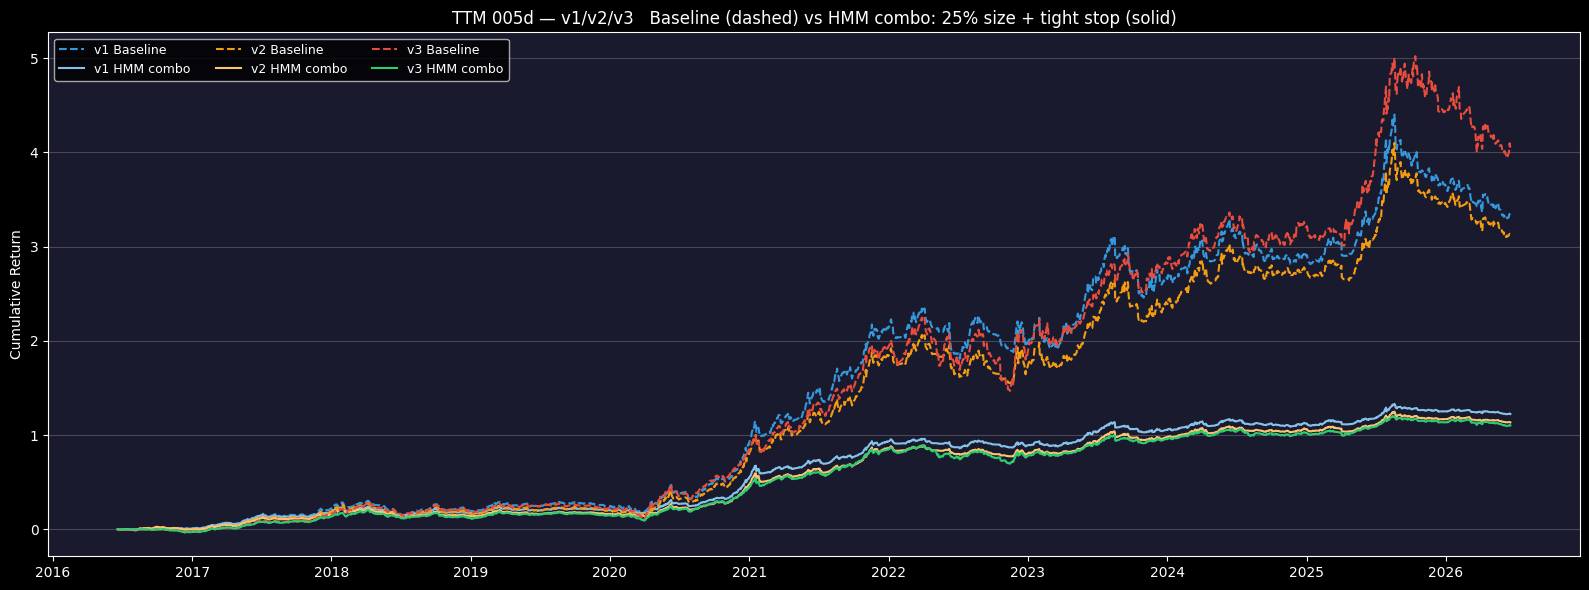

In [57]:
COLORS = {
    ('v1', 'base'): '#3498db', ('v1', 'hmm'): '#85c1e9',
    ('v2', 'base'): '#f39c12', ('v2', 'hmm'): '#f8c471',
    ('v3', 'base'): '#e74c3c', ('v3', 'hmm'): '#2ecc71',
}

fig, ax = plt.subplots(figsize=(16, 6))
ax.set_facecolor('#1a1a2e')
for ver in ['v1', 'v2', 'v3']:
    for kind, ls in [('base', '--'), ('hmm', '-')]:
        pf  = portfolios[(ver, kind)]
        cum = pf.cumulative_returns().mean(axis=1)
        lbl = f'{ver} {"Baseline" if kind=="base" else "HMM combo"}'
        ax.plot(cum.index, cum.values, label=lbl,
                color=COLORS[(ver, kind)], lw=1.5, linestyle=ls)
ax.set_title('TTM 005d — v1/v2/v3   Baseline (dashed) vs HMM combo: 25% size + tight stop (solid)')
ax.set_ylabel('Cumulative Return')
ax.legend(ncol=3, fontsize=9); ax.yaxis.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()


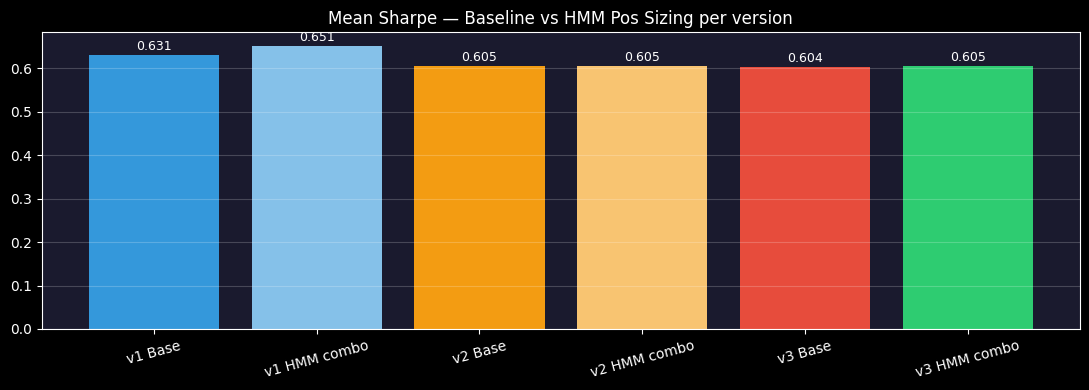

In [58]:
vers   = ['v1', 'v2', 'v3']
labels  = [f'{v} {"Base" if k=="base" else "HMM combo"}' for v in vers for k in ['base','hmm']]
sharpes = [portfolios[(v, k)].sharpe_ratio().mean() for v in vers for k in ['base','hmm']]
colors  = [COLORS[(v, k)] for v in vers for k in ['base','hmm']]

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_facecolor('#1a1a2e')
bars = ax.bar(labels, sharpes, color=colors, edgecolor='none')
ax.axhline(0, color='white', lw=0.5, ls='--')
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, color='white')
ax.set_title('Mean Sharpe — Baseline vs HMM Pos Sizing per version')
ax.tick_params(axis='x', rotation=15); ax.yaxis.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()


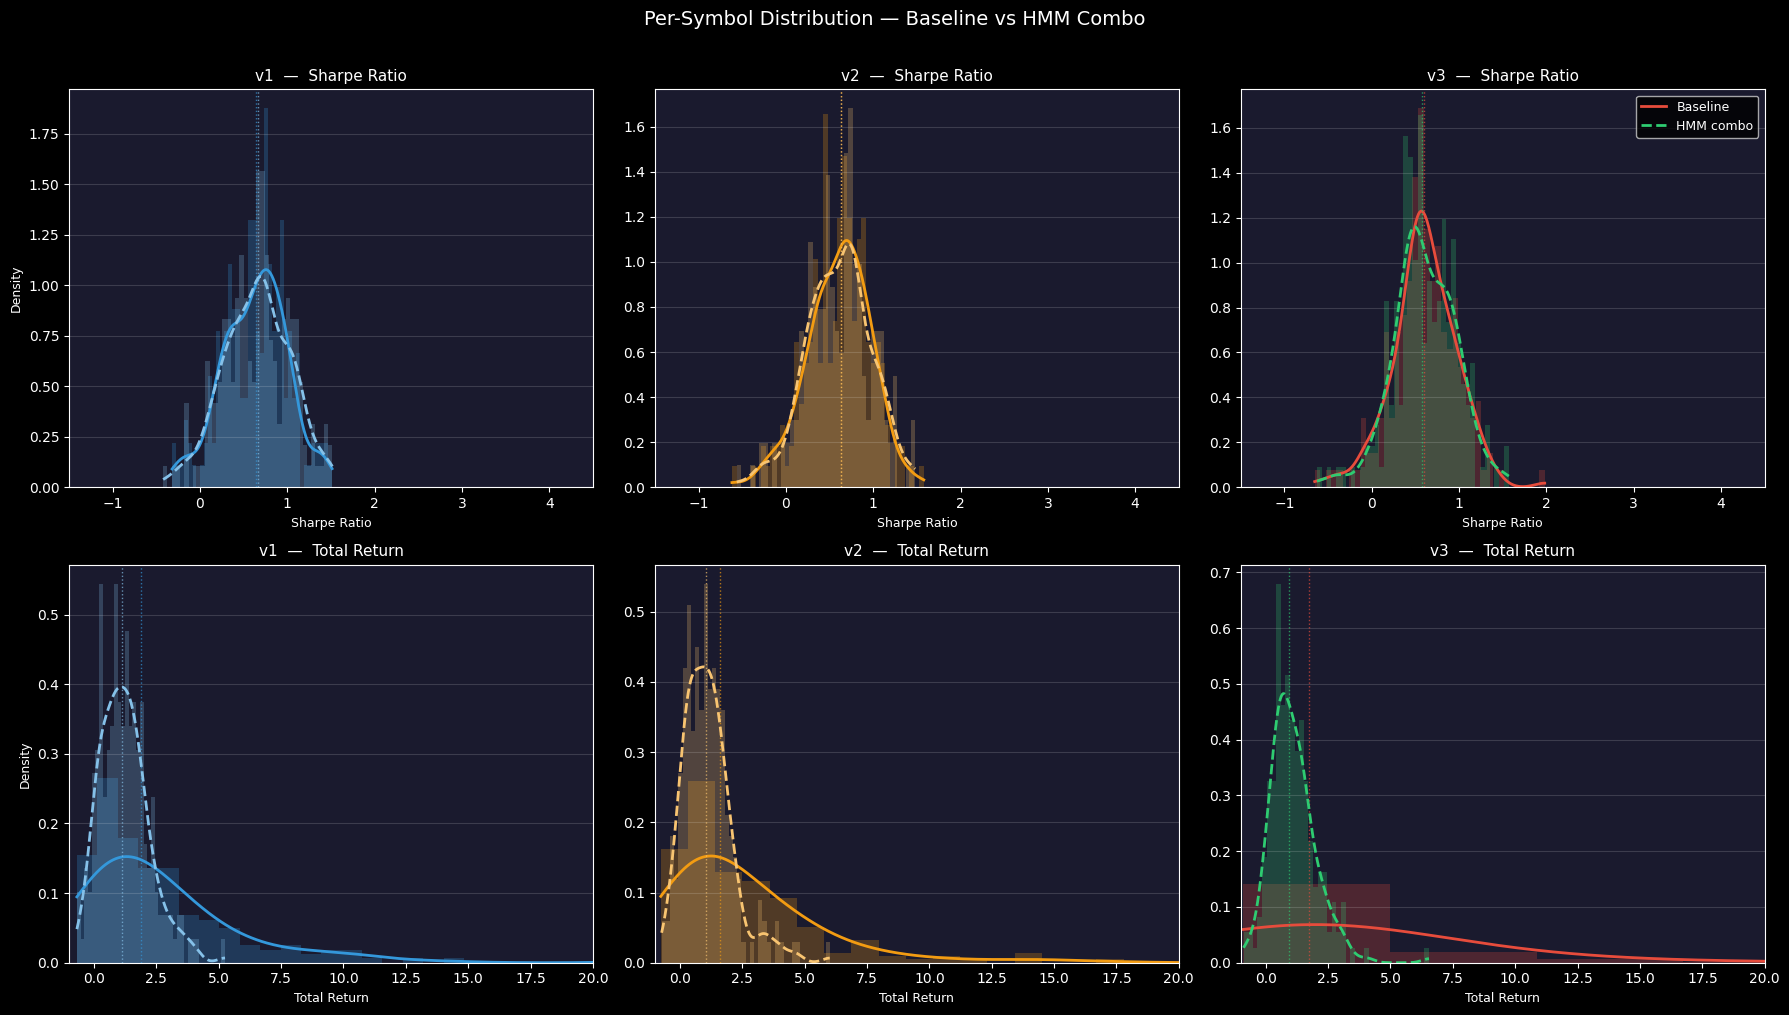

In [59]:
from scipy.stats import gaussian_kde

VERS = ['v1', 'v2', 'v3']
METRICS = [
    ('sharpe_ratio', 'Sharpe Ratio',  (-1.5, 4.5)),
    ('total_return', 'Total Return',  (-1.0, 20.0)),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Per-Symbol Distribution — Baseline vs HMM Combo', fontsize=14, y=1.01)

for row, (metric_fn, metric_label, xlim) in enumerate(METRICS):
    for col, ver in enumerate(VERS):
        ax = axes[row, col]
        ax.set_facecolor('#1a1a2e')

        for kind, label, color, ls in [
            ('base', 'Baseline',  COLORS[(ver, 'base')], '-'),
            ('hmm',  'HMM combo', COLORS[(ver, 'hmm')],  '--'),
        ]:
            vals = (
                getattr(portfolios[(ver, kind)], metric_fn)()
                .replace([np.inf, -np.inf], np.nan).dropna()
            )
            ax.hist(vals, bins=40, alpha=0.25, color=color, density=True)
            try:
                kde = gaussian_kde(vals, bw_method=0.3)
                x   = np.linspace(max(vals.min(), xlim[0]), min(vals.max(), xlim[1]), 400)
                ax.plot(x, kde(x), color=color, lw=2, linestyle=ls, label=label)
            except Exception:
                pass
            ax.axvline(vals.median(), color=color, lw=1, linestyle=':', alpha=0.7)

        ax.set_title(f'{ver}  —  {metric_label}', fontsize=11)
        ax.set_xlim(*xlim)
        ax.set_xlabel(metric_label, fontsize=9)
        ax.set_ylabel('Density' if col == 0 else '', fontsize=9)
        ax.yaxis.grid(True, alpha=0.15)
        if row == 0 and col == 2:
            ax.legend(fontsize=9)

fig.tight_layout()
plt.show()
